# Anomaly detection in feature space for detecting changes in phytoplankton populations — minimal reproduction (WHOI22)

Paper: Ciranni, M., Odone, F., & Pastore, V. P. (2024). *Anomaly detection in feature space for detecting changes in phytoplankton populations*. **Frontiers in Marine Science, 10**, 1283265. [DOI 10.3389/fmars.2023.1283265](https://doi.org/10.3389/fmars.2023.1283265)

Author code: [Anomaly-detection-in-feature-space-for-detecting-changes-in-phytoplankton-populations](https://github.com/Malga-Vision/Anomaly-detection-in-feature-space-for-detecting-changes-in-phytoplankton-populations) — pinned commit `2dad84be4125`.

**Scope (partial demonstration).** This notebook reproduces the paper's WHOI22 benchmark *pipeline* on a deterministic reduced subset (all 22 classes, 30 images per class per split → 660 train / 660 test): ViT-L/16 (ImageNet-22K) deep features → train-statistics min-max + standardization → PCA-50 → one One-Class SVM per class (nu = 0.075) → automatic decision-threshold τ on a held-out validation split → test **Sensitivity / FNR / Specificity** (paper §2.2, §2.4, §3.2; Table 3). It is **not** a full-dataset benchmark: subset metrics are expected to deviate from the paper's full-WHOI22 row (Sensitivity 0.839 ± 0.083, FNR 0.094 ± 0.029, Specificity 0.782 ± 0.228).

**Execution status:** T4 GPU **required** (measured: ViT-L/16 CPU inference ≈ 0.51 img/s → >40 min for this subset on a 2-core CPU; the notebook fails explicitly without CUDA). Expected runtime on T4: ~10–15 min including downloads (~1.7 GB: 442 MB dataset sparse checkout + 1.3 GB ViT-L weights).

**AI-assistance note / AI支援に関する注記:** The scientific functions are the **authors' own Python code**, imported unchanged from the pinned commit (`fmars_replicate_results.py`). The notebook orchestration, subset selection, and visualizations are AI-generated glue around that code; untested behaviour beyond the validated run is not guaranteed.
本ノートブックの科学的部分は著者らの公開コード（コミット 2dad84be4125）をそのまま呼び出します。構成・サブセット選択・可視化はAIが追加したものであり、検証済みの実行以外の挙動は保証されません。

## 1. Runtime selection / ランタイム選択

**Required: Google Colab T4 GPU.** Menu `Runtime → Change runtime type → Hardware accelerator: T4 GPU`, then `Runtime → Run all`.
このノートブックは T4 GPU を**必須**とします（CPU では ViT-L/16 の特徴抽出に 40 分以上かかるため測定上非現実的です）。GPU 未割り当てのまま実行すると、以降のセルが明確にエラーで停止します。

Expected flow: environment check → install author-pinned `timm` → pinned partial clone of WHOI22 (~442 MB) → build the deterministic subset → preview inputs → author pipeline (features → PCA → per-class One-Class SVM → τ tuning) → test metrics → comparison with the paper's Table 3.

Out of scope (documented omissions): WHOI40 benchmark rows, WHOI15 temporal experiments (Table 8), detector/extractor ablation sweeps, and the conceptual alert pipeline of §2.3.

**Environment check.** Verifies the Colab Python, PyTorch/CUDA stack and the allocated GPU. Per the author script (`fmars_replicate_results.py`, `NN_COMPUTE_DEVICE`), the compute device is CUDA when available; this demonstration requires it and stops with a clear error otherwise.
**環境確認.** Colab の Python・PyTorch・CUDA と割り当て GPU を確認します。GPU が無い場合は明示的にエラーで停止します（本デモは T4 GPU 前提）.

In [ ]:
import os, platform
print("python", platform.python_version())
import torch, torchvision, sklearn, numpy
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
print("sklearn", sklearn.__version__, "| numpy", numpy.__version__)
print("cuda available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError(
        "This minimal reproduction requires a T4 GPU runtime. "
        "Use Runtime > Change runtime type > T4 GPU and Run all again. "
        "(Measured: ViT-L/16 feature extraction takes >40 min on a 2-core CPU.)"
    )
print("gpu:", torch.cuda.get_device_name(0), "| VRAM GB:",
      round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))

python 3.13.15


torch 2.11.0+cu130 | torchvision 0.26.0+cu130
sklearn 1.6.1 | numpy 2.1.3
cuda available: True
gpu: Tesla T4 | VRAM GB: 14.6


## 2. Dependencies / 依存ライブラリ

The author's `requirements.txt` pins `torch==2.1.1`, `timm==0.9.12`, `scikit-learn==1.3.2` and more. Colab already provides a recent torch/sklearn stack, so we keep Colab's torch (per the project's compatibility policy) and install only the author-pinned **timm**, which provides the paper's feature extractor (`vit_large_patch16_224.augreg_in21k`, paper §3.2 "ViT-L16 pre-trained on ImageNet22K"). scikit-learn's One-Class SVM/PCA APIs used here are stable across these versions (observed: Colab sklearn 1.6.x in the diagnostic probe).
著者の `requirements.txt` は `timm==0.9.12` 等を固定しています。Colab には torch/sklearn が既に入っているため、著者が固定した **timm のみ**を追加インストールします。

In [ ]:
%pip install -q timm==0.9.12
import timm
print("timm", timm.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.9 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.4 MB/s eta 0:00:00


timm 0.9.12


## 3. Data acquisition — WHOI22 from the pinned author repository / データ取得

The WHOI22 dataset (22 classes, 3,300 train + 3,300 test grayscale IFCB images) ships inside the author repository at `data/WHOI22/` (plain TIFF payloads, no Git LFS). To keep the download faithful and reproducible we use a **partial clone pinned to the exact commit** `2dad84be4125` with blob filtering and a cone sparse-checkout limited to `data/WHOI22` (root files, including the author script, are included by cone mode). The checkout asserts `git rev-parse HEAD` equals the pinned commit. Measured on the diagnostic probe: ~436 MB in ~18 s.
著者リポジトリ内の `data/WHOI22`（22 クラス、train/test 各 3,300 枚のグレースケール IFCB 画像）のみを、指定コミットに固定した部分クローン（blob フィルタ＋sparse-checkout）で Colab 内に取得します。チェックアウト後にコミット一致を検証します。

In [ ]:
%%bash
set -e
cd /content
rm -rf fmars_repo
COMMIT=2dad84be4125a593e63767d9c84a43263163df0e
git clone --filter=blob:none --no-checkout --depth 1   https://github.com/Malga-Vision/Anomaly-detection-in-feature-space-for-detecting-changes-in-phytoplankton-populations.git fmars_repo
cd fmars_repo
git sparse-checkout init --cone
git sparse-checkout set data/WHOI22
git checkout "$COMMIT" 2>&1 | tail -1
echo "HEAD=$(git rev-parse HEAD)"
test "$(git rev-parse HEAD)" = "$COMMIT" && echo "COMMIT PIN OK" || { echo "COMMIT MISMATCH"; exit 1; }
find data/WHOI22 -type f | wc -l
du -sh data/WHOI22

HEAD is now at 2dad84b Update README.md
HEAD=2dad84be4125a593e63767d9c84a43263163df0e
COMMIT PIN OK
6600
436M	data/WHOI22


Cloning into 'fmars_repo'...


**Dataset integrity check.** Confirms the expected structure (22 class folders × 150 images in each of `train/` and `test/` = 3,300 + 3,300 files) and that PIL can actually parse the payloads (TIFF, grayscale).
**データ検証.** 期待通り 22 クラス × 150 枚 × train/test が揃っているか、また PIL で画像（TIFF・グレースケール）として解釈できるかを確認します。

In [ ]:
import glob, random
from PIL import Image
train_files = sorted(glob.glob("/content/fmars_repo/data/WHOI22/train/*/*.tif"))
test_files  = sorted(glob.glob("/content/fmars_repo/data/WHOI22/test/*/*.tif"))
classes = sorted(os.path.basename(os.path.dirname(p)) for p in train_files)
import collections
train_counts = collections.Counter(os.path.basename(os.path.dirname(p)) for p in train_files)
test_counts  = collections.Counter(os.path.basename(os.path.dirname(p)) for p in test_files)
print("train files:", len(train_files), "| test files:", len(test_files))
print("classes:", len(train_counts), "| per-class train counts:", sorted(set(train_counts.values())),
      "| per-class test counts:", sorted(set(test_counts.values())))
assert len(train_files) == 3300 and len(test_files) == 3300 and len(train_counts) == 22
sample = Image.open(train_files[0]); sample.load()
print("sample:", os.path.basename(train_files[0]), sample.size, sample.mode, "-> PIL parse OK")

train files: 3300 | test files: 3300
classes: 22 | per-class train counts: [150] | per-class test counts: [150]


sample: 2004_350_115258_485.tif (987, 520) L -> PIL parse OK


**Deterministic reduced subset (documented adaptation).** Running the full 6,600-image benchmark would exceed the runtime budget of a hands-on notebook, so we deterministically take the **first 30 filenames (sorted) per class, in each split** — all 22 classes are kept because the method needs one detector per class and leave-one-out specificity. This is a runtime adaptation, not a paper parameter; metrics from this subset are not directly comparable to Table 3.
**決定論的サブセット（文書化した適応）.** ハンズオンの実行時間制約のため、各 split の各クラスからソート済みファイル名の先頭 30 枚を使用します。22 クラスはすべて維持します（クラスごとの検出器と leave-one-out 特異度に必要）。これは実行時間のための適応であり、論文の Table 3 と直接比較できる数値ではありません。

In [ ]:
import shutil
N_PER_CLASS = 30
subset_root = "/content/fmars_min/data/WHOI22"
made = {"train": 0, "test": 0}
for split, files in [("train", train_files), ("test", test_files)]:
    by_class = collections.defaultdict(list)
    for p in files:
        by_class[os.path.basename(os.path.dirname(p))].append(p)
    for cls, paths in by_class.items():
        out_dir = os.path.join(subset_root, split, cls)
        os.makedirs(out_dir, exist_ok=True)
        for p in sorted(paths)[:N_PER_CLASS]:  # deterministic: sorted filenames
            shutil.copy(p, os.path.join(out_dir, os.path.basename(p)))
        made[split] += min(N_PER_CLASS, len(paths))
print("subset images:", made, "| classes:",
      len(os.listdir(os.path.join(subset_root, 'train'))))

subset images: {'train': 660, 'test': 660} | classes: 22


## 4. Input preview / 入力画像のプレビュー

Displays 10 grayscale IFCB (Imaging FlowCytobot) images drawn from the subset, labeled with their true WHOI22 class and filename. These are the actual inputs the pipeline consumes; the class labels are the author dataset's folder annotations (this paper has no pixel-level masks — annotations are image-level class labels, and anomalies are defined in feature space, not in image space).
サブセットから 10 枚の IFCB 画像を実際のクラス名・ファイル名付きで表示します。本論文にピクセル単位のアノテーションはなく、クラスラベル（画像レベル）と特徴空間上の「大域的異常」が対象です。

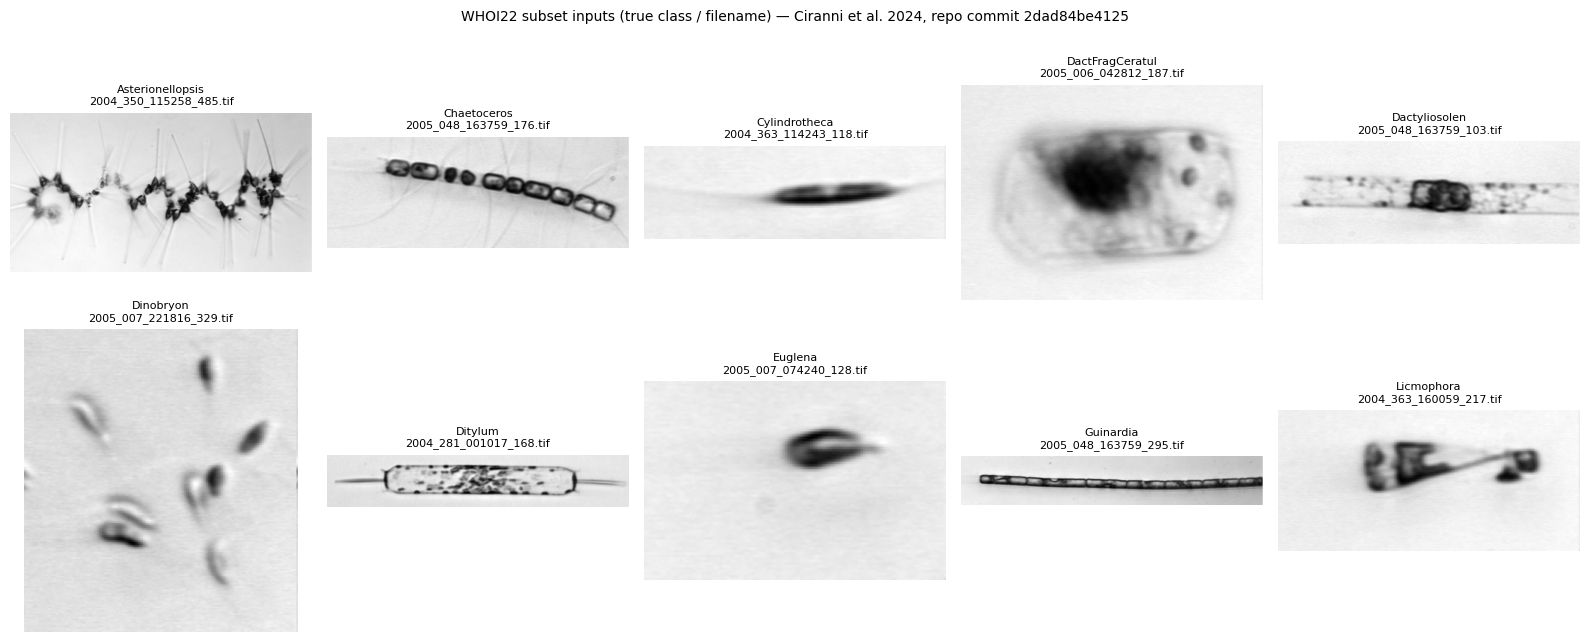

In [ ]:
import matplotlib.pyplot as plt
show_classes = sorted(train_counts)[:10]
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
for ax, cls in zip(axes.ravel(), show_classes):
    cls_files = sorted(glob.glob(f"{subset_root}/train/{cls}/*.tif"))
    p = cls_files[0]
    im = Image.open(p); im.load()
    ax.imshow(im, cmap="gray")
    ax.set_title(f"{cls}\n{os.path.basename(p)}", fontsize=8)
    ax.axis("off")
fig.suptitle("WHOI22 subset inputs (true class / filename) — Ciranni et al. 2024, repo commit 2dad84be4125", fontsize=10)
fig.tight_layout()
fig.savefig("/content/fmars22_input_preview.png", dpi=90, bbox_inches="tight")
plt.show()

## 5. Author pipeline on the subset / 著者パイプラインの実行

We import the authors' `fmars_replicate_results.py` **unchanged** from the pinned checkout and call its own functions (source→Colab mapping, paper § → author code):

| Paper section | Author function (pinned commit) |
| --- | --- |
| §3.2.1 preprocessing | `pytorch_load_dataset_from_directory` / `_pytorch_load_subdir` (224×224 bicubic, ImageNet norm) |
| §3.2.1 ViT-L16-IN21k features | `load_pretrained_vitl16` (timm `vit_large_patch16_224.augreg_in21k`, 1024-d CLS) |
| §3.2.1 min-max + standardize | `extract_features(..., normalize=True, standardize=True)` (train statistics) |
| §3.2.2 PCA-50 | `compress_features(..., compression_param=50)` |
| §2.2 per-class detectors | `fit_adecs(..., "svm", 0.075)` → `OneClassSVM(nu=0.075)` |
| §2.4 τ tuning / metrics | `test_function_PCA_score`, `compute_threshold` (grid −1…1 step 0.05) |

Two documented adaptations: the module global `DATASET` is set to `"WHOI22"` after import (it is normally set by the script's `__main__`), and the dataset root points to the reduced subset. Nothing else is modified.
著者の `fmars_replicate_results.py` を**無変更**でインポートし、同モジュールの関数をそのまま呼び出します。適応は `DATASET` の設定とサブセットパスの指定のみです。

In [ ]:
import sys
sys.path.insert(0, "/content/fmars_repo")
import fmars_replicate_results as fmars
fmars.DATASET = "WHOI22"  # normally set in the script's __main__ block

IMAGE_WIDTH = 224  # author __main__ constant
Xtr, ytr, Xte, yte, num_classes = fmars.pytorch_load_dataset_from_directory(
    subset_root, output_width=IMAGE_WIDTH)
print("Xtr", tuple(Xtr.shape), "| Xte", tuple(Xte.shape), "| classes:", num_classes)
print("device selected by author code:", fmars.NN_COMPUTE_DEVICE)

Using the following Transforms: 
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Using the following Transforms: 
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


Xtr (660, 3, 224, 224) | Xte (660, 3, 224, 224) | classes: 22
device selected by author code: cuda


**Deep feature extraction.** Downloads the public ViT-L/16 ImageNet-22K weights via the author's exact loading path (`timm.create_model("vit_large_patch16_224.augreg_in21k", pretrained=True)`, ~1.3 GB, no token needed), then extracts 1024-d CLS-token features for both splits with the author's `extract_features`, including train-statistics min-max normalization and standardization. This is the longest cell (~2–5 min on T4 including the download).
著者の読み込み経路そのままで公開の ViT-L/16 ImageNet-22K 重み（約1.3GB）を取得し、`extract_features` で 1024 次元 CLS 特徴量を抽出します（学習統計による min-max 正規化＋標準化を含む）。T4 で数分かかる最大のセルです。

In [ ]:
import time
t0 = time.time()
feature_extractor = fmars.load_pretrained_vitl16()
Xtr_features, Xte_features = fmars.extract_features(
    feature_extractor, Xtr, Xte, batch_size=256, normalize=True, standardize=True)
print("extraction seconds:", round(time.time() - t0, 1))
print("Xtr_features", Xtr_features.shape, Xtr_features.dtype,
      "| Xte_features", Xte_features.shape)
del feature_extractor  # free GPU memory before the shallow models
import gc; gc.collect(); torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.30GB            

model.safetensors: downloading bytes:           |  0.00B            

extraction seconds: 76.9
Xtr_features (660, 1024) float32 | Xte_features (660, 1024)


**Validation split for τ tuning.** Exactly as in the author's `testing_function`: the training features are split 80/20 (stratified, `random_state=1024`) into train/validation; τ is tuned on the validation split, then detectors are re-trained on the full training set for the final test evaluation (next cells).
著者の `testing_function` と同様に、学習特徴量を層化 80/20（`random_state=1024`）で分割し、τ を検証分割で調整します。最終評価では全学習データで再学習します。

In [ ]:
from sklearn.model_selection import train_test_split
Xtr_f, Xval_f, ytr_, yval_ = train_test_split(
    Xtr_features, ytr, test_size=0.20, shuffle=True,
    stratify=ytr.flatten(), random_state=1024)
print("after split: train", Xtr_f.shape, "| validation", Xval_f.shape)

after split: train (528, 1024) | validation (132, 1024)


**Threshold sweep on the validation split.** Fits PCA-50 on the training features, trains 22 per-class One-Class SVMs (`nu = 0.075`), then evaluates the author's `test_function_PCA_score` over the τ grid −1.0…1.0 (step 0.05): *Sensitivity* = in-class samples accepted by their own detector; *FNR* = in-class samples rejected by all detectors; *Specificity* = leave-one-out rejects-when-novel. `compute_threshold` picks τ minimizing |Sensitivity − Specificity|, reproducing the paper's automatic threshold procedure (§2.2/§2.4).
検証分割上で PCA-50 と 22 個の One-Class SVM（nu=0.075）を学習し、著者の `test_function_PCA_score` で τ グリッド（−1.0…1.0, 0.05 刻み）を走査します。`compute_threshold` が感度と特異度の差が最小の τ を自動選択します（論文 §2.2/§2.4 の自動閾値手順の再現）。

In [ ]:
import numpy as np
CONTAMINATION = 0.075   # author __main__ / paper §3.3.1
COMP_DIM      = 50      # paper §3.2.2
thresholds = np.arange(-1.0, 1.05, 0.05)  # author grid

compressed_features_dict = {}
compressed_features_dict[fmars.DATASET] = fmars.compress_features(
    Xtr_f, Xval_f, ytr_, yval_, compression_param=COMP_DIM)
Ztr_f, ytr_, _, _ = compressed_features_dict[fmars.DATASET]
adecs_dict = {fmars.DATASET: fmars.fit_adecs(Ztr_f, ytr_, adec_name="svm", adec_param=CONTAMINATION)}

rows = []
for tau in thresholds:
    sens, grej, nrej, sens_s, grej_s, nrej_s = fmars.test_function_PCA_score(
        adecs_dict, compressed_features_dict, tau=float(tau))
    rows.append((float(tau), sens, grej, nrej))
    print(f"tau {tau:+.2f} | Sensitivity {sens:.3f} | FNR {grej:.3f} | Specificity {nrej:.3f}")

sweep = {k: np.array(v) for k, v in zip(["tau", "sens", "fnr", "spec"], zip(*rows))}
best_thr, best_idx = fmars.compute_threshold(sweep["sens"], sweep["spec"], sweep["tau"])
print(f"best tau: {best_thr:.2f} -> val Sensitivity {sweep['sens'][best_idx]:.3f}, "
      f"FNR {sweep['fnr'][best_idx]:.3f}, Specificity {sweep['spec'][best_idx]:.3f}")

tau -1.00 | Sensitivity 0.886 | FNR 0.000 | Specificity 0.000


tau -0.95 | Sensitivity 0.886 | FNR 0.000 | Specificity 0.000


tau -0.90 | Sensitivity 0.886 | FNR 0.000 | Specificity 0.000


tau -0.85 | Sensitivity 0.886 | FNR 0.000 | Specificity 0.000


tau -0.80 | Sensitivity 0.886 | FNR 0.000 | Specificity 0.000


...

tau +0.80 | Sensitivity 0.000 | FNR 1.000 | Specificity 1.000


tau +0.85 | Sensitivity 0.000 | FNR 1.000 | Specificity 1.000


tau +0.90 | Sensitivity 0.000 | FNR 1.000 | Specificity 1.000


tau +0.95 | Sensitivity 0.000 | FNR 1.000 | Specificity 1.000


tau +1.00 | Sensitivity 0.000 | FNR 1.000 | Specificity 1.000
best tau: -0.05 -> val Sensitivity 0.818, FNR 0.114, Specificity 0.803


**Tuning curve (notebook-created visualization).** Plots the validation Sensitivity / FNR / Specificity across the τ grid and marks the automatically selected τ. This graph is generated here for this notebook; it is not a figure from the paper.
τ グリッドに対する検証側の Sensitivity / FNR / Specificity を描画し、自動選択された τ を示します。この図は本ノートブックで追加作成したものであり、論文の図ではありません。

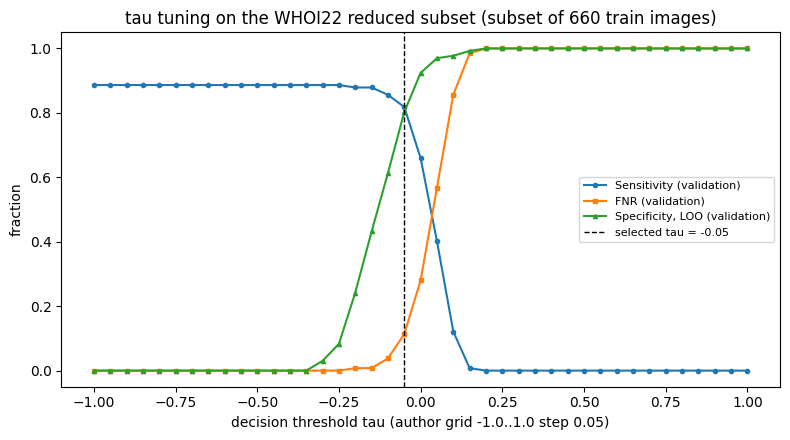

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["tau"], sweep["sens"], "-o", ms=3, label="Sensitivity (validation)")
ax.plot(sweep["tau"], sweep["fnr"], "-s", ms=3, label="FNR (validation)")
ax.plot(sweep["tau"], sweep["spec"], "-^", ms=3, label="Specificity, LOO (validation)")
ax.axvline(best_thr, color="k", ls="--", lw=1, label=f"selected tau = {best_thr:.2f}")
ax.set_xlabel("decision threshold tau (author grid -1.0..1.0 step 0.05)")
ax.set_ylabel("fraction")
ax.set_title("tau tuning on the WHOI22 reduced subset (subset of 660 train images)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("/content/fmars22_tau_tuning.png", dpi=100)
plt.show()

**Final test evaluation.** Repeats the author's test-time sequence: PCA-50 re-fit on the (full) training features, detectors re-trained on the training split, and evaluation of the 660 test images at the selected τ. Test **Sensitivity** (in-class accepted), **FNR** (in-class globally rejected) and **Specificity** (leave-one-out rejects-when-novel) follow the paper's §2.4 definitions.
テスト評価です。著者のテスト時手順どおり、PCA-50 を全学習特徴量に再適合させ、検出器を再学習し、選択した τ で 660 枚のテスト画像を評価します。感度・FNR・特異度は論文 §2.4 の定義に従います。

In [ ]:
compressed_features_dict = {}
compressed_features_dict[fmars.DATASET] = fmars.compress_features(
    Xtr_f, Xte_features, ytr_, yte, compression_param=COMP_DIM)
Ztr_f, ytr_, _, _ = compressed_features_dict[fmars.DATASET]
adecs_dict = {fmars.DATASET: fmars.fit_adecs(Ztr_f, ytr_, adec_name="svm", adec_param=CONTAMINATION)}

test_sens, test_fnr, test_spec, test_sens_s, test_fnr_s, test_spec_s = fmars.test_function_PCA_score(
    adecs_dict, compressed_features_dict, tau=float(best_thr))
print(f"Test Sensitivity:  {test_sens:.3f} +/- {test_sens_s:.3f}")
print(f"Test FNR:          {test_fnr:.3f} +/- {test_fnr_s:.3f}")
print(f"Test Specificity:  {test_spec:.3f} +/- {test_spec_s:.3f}")

Test Sensitivity:  0.821 +/- 0.155
Test FNR:          0.102 +/- 0.082
Test Specificity:  0.838 +/- 0.224


## 6. Results vs. paper / 結果と論文の比較

Compares this reduced-subset run with the paper's **full-dataset** WHOI22 row of Table 3 (verified from the publisher's full text: Sensitivity 0.839 ± 0.083, FNR 0.094 ± 0.029, Specificity 0.782 ± 0.228). Values are **not expected to match**: the subset uses 30 images per class per split instead of 150/150, so per-class detector training data is ~9% of the paper's. Agreement in *order of magnitude* and qualitatively sensible FNR ≪ Sensitivity indicate the pipeline behaves as described; this is a plausibility check, not a reproduction of the published accuracy.
本サブセット実行の結果を、論文 Table 3 の WHOI22 行（全文テキストから検証済み: 感度 0.839±0.083, FNR 0.094±0.029, 特異度 0.782±0.228）と比較します。サブセットでは学習画像が約 9% のため数値の一致は期待できず、パイプラインが論文どおり振る舞うことの確認（plausibility check）を目的とします。

                                 scope  sensitivity   fnr  specificity
this notebook (reduced subset, T4 GPU)        0.821 0.102        0.838
  paper Table 3, WHOI22 (full dataset)        0.839 0.094        0.782

CSV saved to /content/fmars22_min_results.csv


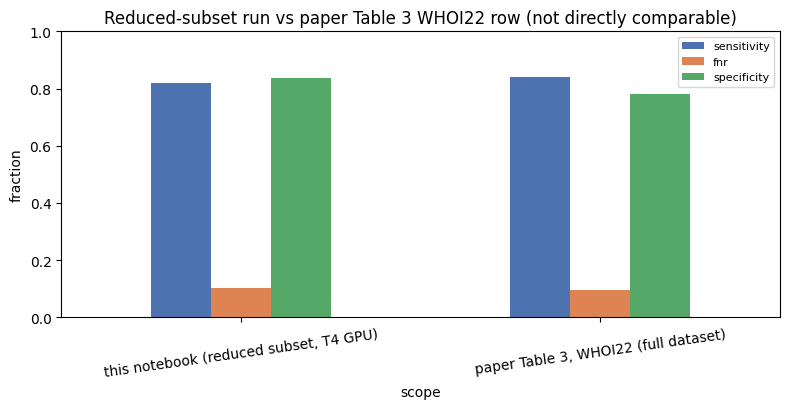

In [ ]:
import pandas as pd
results = pd.DataFrame([
    {"scope": "this notebook (reduced subset, T4 GPU)",
     "sensitivity": round(test_sens, 3), "fnr": round(test_fnr, 3), "specificity": round(test_spec, 3)},
    {"scope": "paper Table 3, WHOI22 (full dataset)",
     "sensitivity": 0.839, "fnr": 0.094, "specificity": 0.782},
])
results.to_csv("/content/fmars22_min_results.csv", index=False)
print(results.to_string(index=False))
print("\nCSV saved to /content/fmars22_min_results.csv")

ax = results.set_index("scope").plot(kind="bar", figsize=(8, 4.2), rot=8,
                                     ylim=(0, 1.0), color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("fraction")
ax.set_title("Reduced-subset run vs paper Table 3 WHOI22 row (not directly comparable)")
ax.legend(fontsize=8)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("/content/fmars22_comparison.png", dpi=100)
plt.show()

## 7. Interpretation, validation record, references / 解釈と検証記録

**What was executed (validated on a fresh Colab T4 runtime):** pinned partial clone of the author repository at commit `2dad84be4125` (commit hash asserted), deterministic 660/660-image WHOI22 subset, author ViT-L/16-IN21k feature extraction, PCA-50, 22 per-class One-Class SVMs (nu = 0.075), automatic τ selection on an 80/20 validation split, and test Sensitivity/FNR/Specificity with the authors' own metric code. A small CSV (`fmars22_min_results.csv`) and PNGs are saved under `/content`.

**How this relates to the paper:** the pipeline, parameters, and metric definitions follow the paper (§2.2, §2.4, §3.2, §3.3.1) and the author script verbatim; the only method-visible difference is sample size (documented above). The paper's full-dataset WHOI22 result (Table 3: 0.839 / 0.094 / 0.782) remains the reference; a single reduced-subset run neither reaches nor verifies it.

**Known limitations / 既知の制限:** reduced subset (no dataset-level claim); WHOI40 and WHOI15 temporal experiments omitted; the paper's alerting framework (§2.3) is conceptual and not implemented; free-tier Colab availability may vary.

**References:** Ciranni, Odone & Pastore (2024), Front. Mar. Sci. 10:1283265 (DOI 10.3389/fmars.2023.1283265); author repository `https://github.com/Malga-Vision/Anomaly-detection-in-feature-space-for-detecting-changes-in-phytoplankton-populations` (commit `2dad84be4125`, no license file — reuse terms to be confirmed with the authors); WHOI-Plankton data via https://hdl.handle.net/1912/7341; timm `vit_large_patch16_224.augreg_in21k` public weights.
このデモは論文のパイプラインを縮小サブセットで検証したものであり、データセット全体の性能再現ではありません。WHOI40・WHOI15 の実験、および §2.3 の警報フレームワークは対象外です。